In [91]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

In [92]:
titolo = "Confronto"
xlabel = "f (Hz)"
ylabel = ""

file_input1 = "dati_A.csv"
file_input2 = "dati_phi.csv"
files_input = [file_input1,file_input2]

In [93]:
file_output1 = "regressione.txt"
file_output2 = "residui.txt"
file_output3 = "chi.txt"
grafico_output1 = "regressione.pdf"
grafico_output2 = "residui.pdf"
grafico_output3 = "chi.pdf"

cartella = "Analisi"

In [94]:
import os
os.makedirs(cartella, exist_ok=True)

# 1. Lettura

In [95]:
data = {}
keys = ["A","phi"]
for key,file_input in zip(keys, files_input):
    dati = f.csv_to_dict(file_input)

    xdata = np.array([dati["x"],dati["sx"]])
    ydata = np.array([dati["y"],dati["sy"]])

    data[key] = np.array([xdata, ydata])

# 2. Analisi

Modelli con offset

In [96]:
def modello_A(par, x):
    return 1/np.sqrt(1 + ( (x + par[1]) /par[0])**2) + par[2]

def modello_phi(par, x):
    return np.arctan( (x + par[1]) /par[0]) + par[2]

modelli = {
    'A' : modello_A,
    'phi' : modello_phi
}

parametri_labels = {
    'A' : ['f_t', 'f_off', 'A_off'],
    'phi' : ['f_t', 'f_off', 'phi_off']
}

beta = {
    'A' : [1000, 0, 0],
    'phi' : [1000, 0, 0]
}

Regressione

In [97]:
analisi = {}
for key in keys:
    xdata, ydata = data[key]
    modello = modelli[key]
    param_labels = parametri_labels[key]
    beta0 = beta[key]
    anal = f.fit(xdata,ydata,modello,beta0,chi=True)

    analisi[key] = anal

    f.inizializza_output(cartella + f"/{key}_" + file_output1)
    gf.salva_analisi(anal, param_labels, cartella + f"/{key}_" + file_output1)

Residui

In [98]:
residui = {}
for key in keys:
    xdata, ydata = data[key]
    modello = modelli[key]
    anal = analisi[key]

    residui[key] = res

    f.inizializza_output(cartella + f"/{key}_" + file_output2)
    res = f.residui(xdata,ydata,anal[:,0],modello,cartella + f"/{key}_" + file_output2,titolo)

Chi Quadro

In [99]:
chi_quadri = {}
for key in keys:
    xdata, ydata = data[key]
    modello = modelli[key]
    anal = analisi[key]

    chi_quadri[key] = chi

    f.inizializza_output(cartella + f"/{key}_" + file_output3)
    chi = f.chi_quadro(xdata,ydata,anal[:,0],modello,cartella + f"/{key}_" + file_output3,titolo)

# 3. Grafici

Regressione

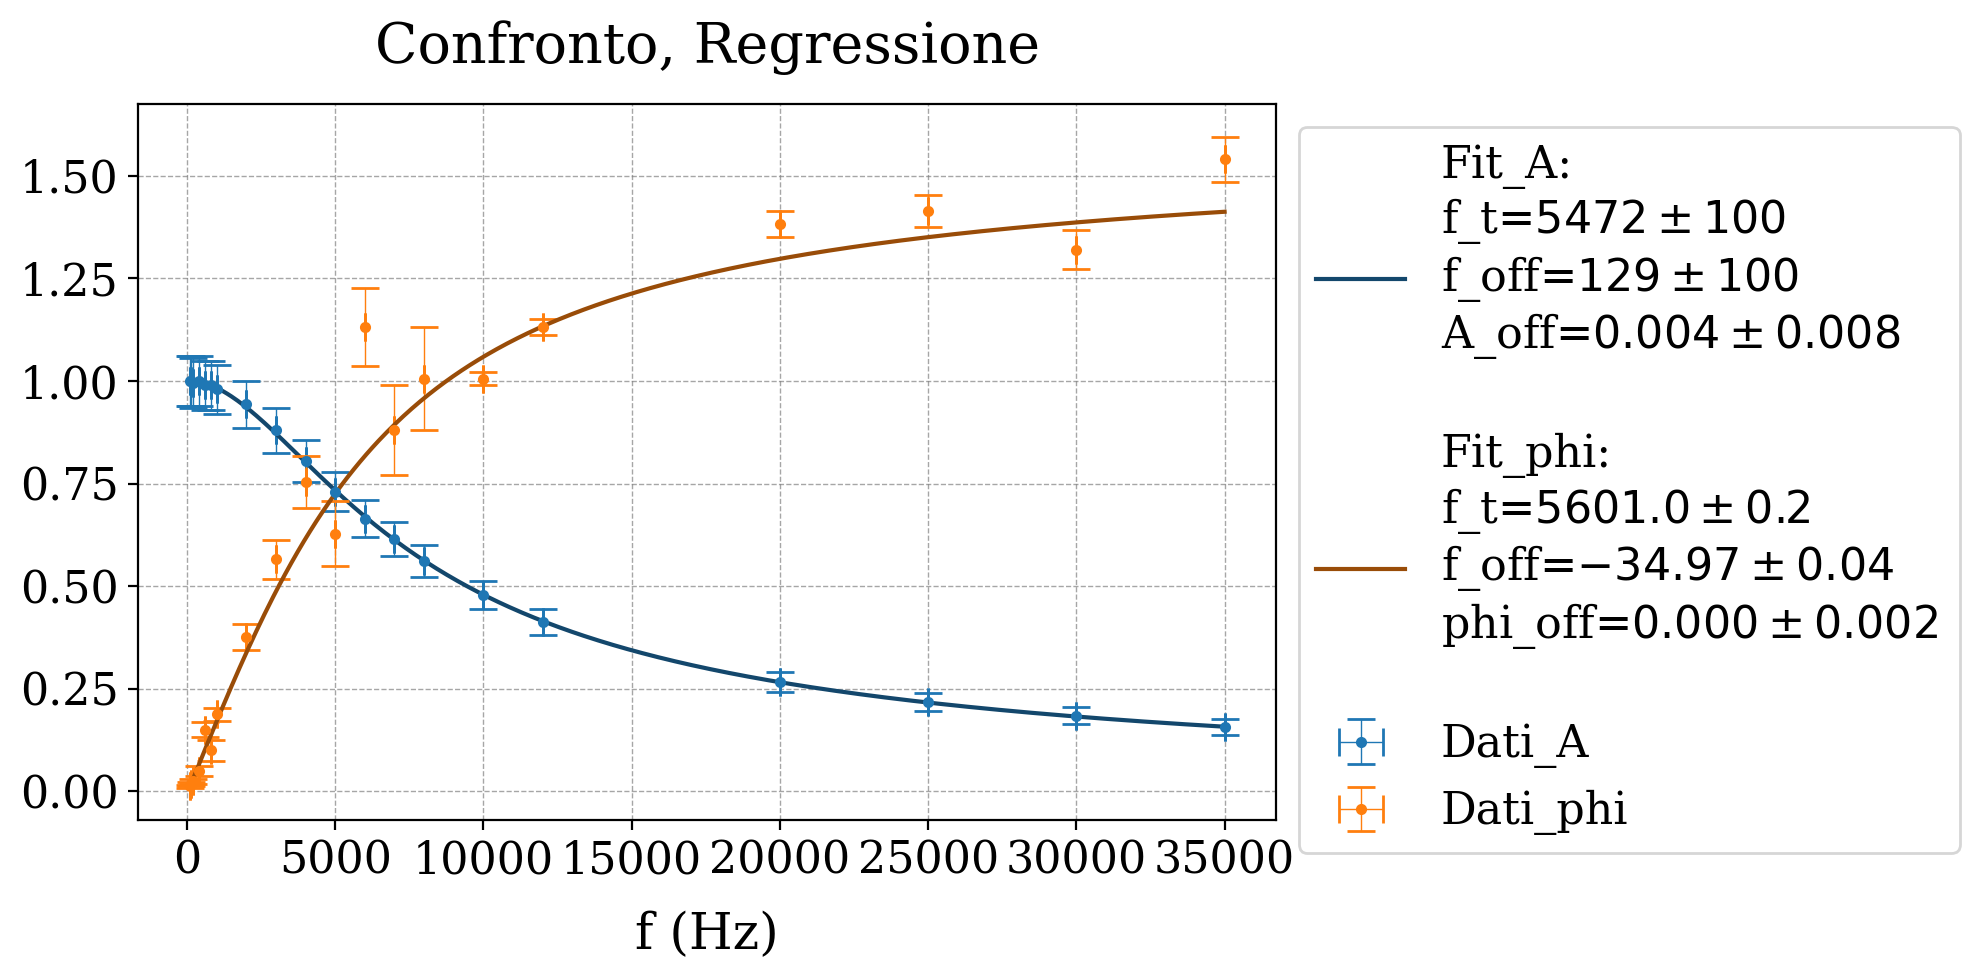

In [100]:
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + ", Regressione",xlabel=xlabel,ylabel=ylabel)

for j,key in enumerate(keys):
    xdata, ydata = data[key]
    anal = analisi[key]
    modello = modelli[key]
    param_labels = parametri_labels[key]
    # Grafico dei dati con errori
    ax.errorbar(xdata[0],ydata[0],xerr=xdata[1],yerr=ydata[1],
                label=f"Dati_{key}", **gf.errorbar_params, color = gf.colori[j])
    # Grafico del fit
    fit_label = f"Fit_{key}:\n" + "".join(
        f"{param_labels[i]}={gf.formatta_errore(anal[i,0],anal[i,1])}\n" for i in range(len(param_labels))
    )
    x_fit = np.linspace(min(xdata[0]), max(xdata[0]), 500)
    ax.plot(x_fit,modello(anal[:,0],x_fit),
            label=fit_label, **gf.plot_params, color = gf.darken(gf.colori[j]))

ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

gf.salva_grafico(fig,cartella + "/" + grafico_output1)

Residui

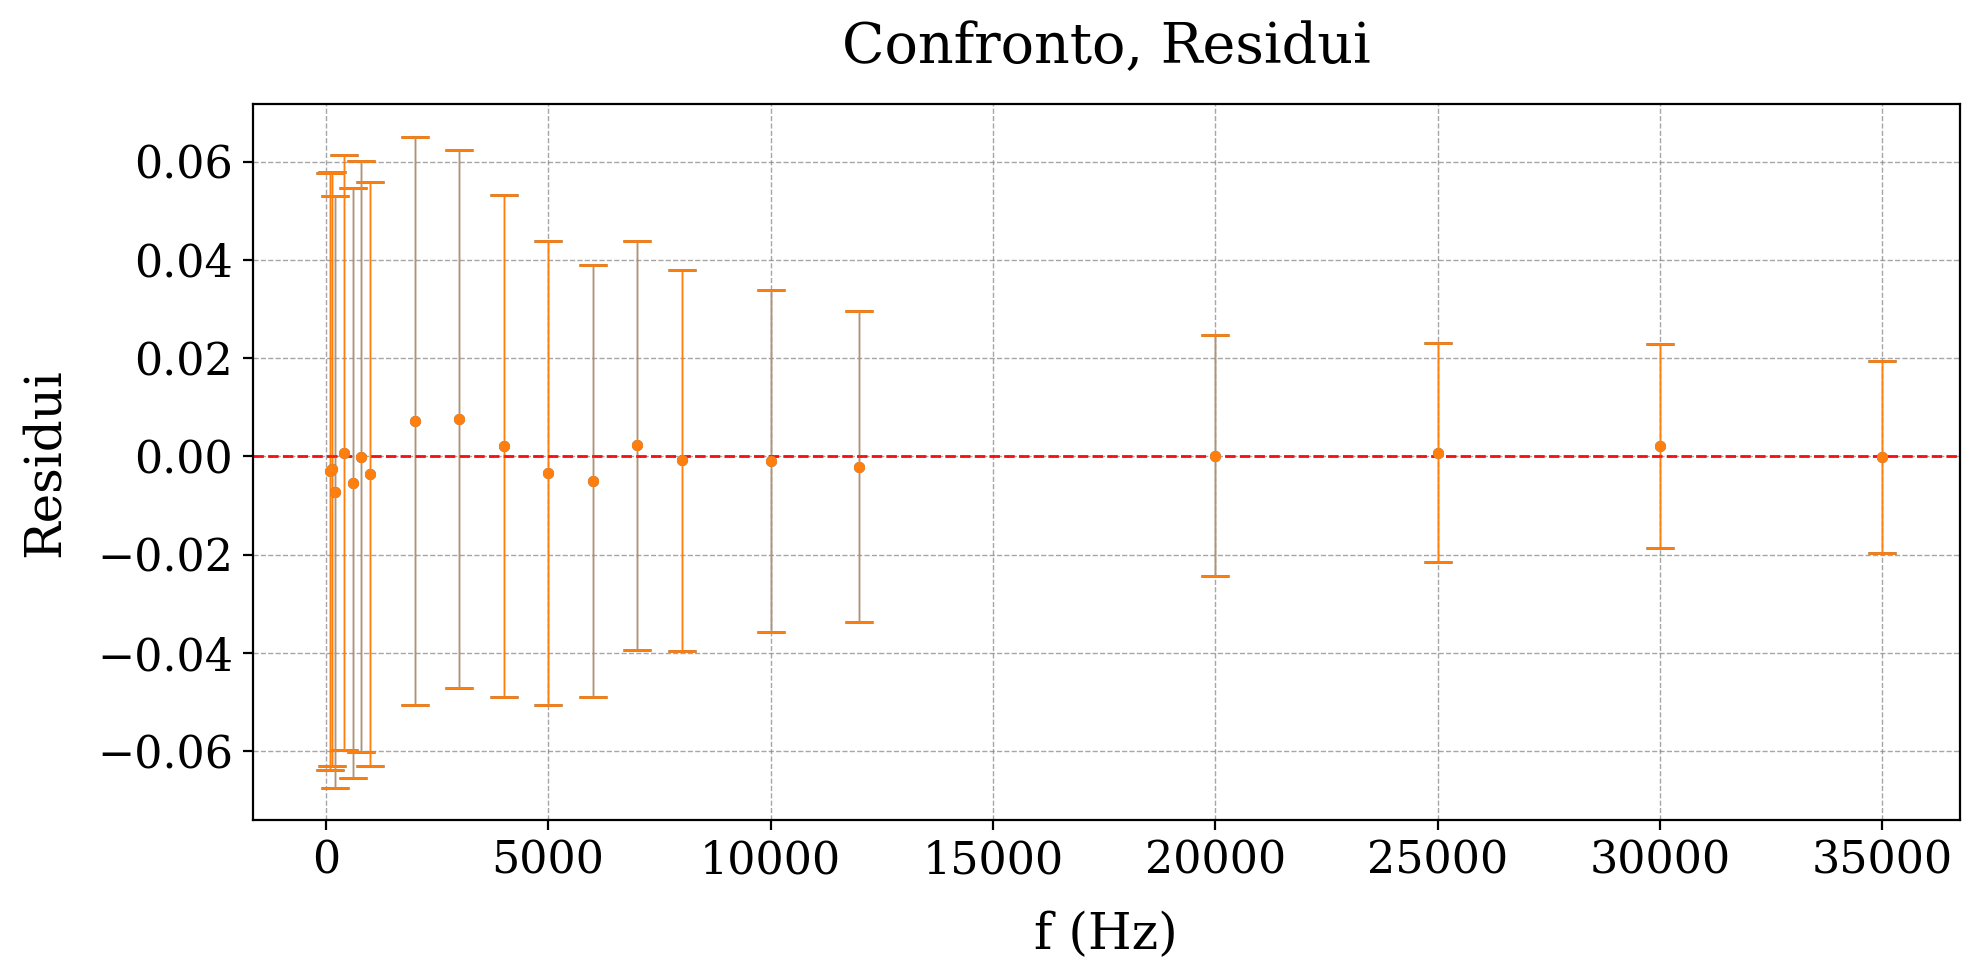

In [101]:
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + ", Residui",xlabel=xlabel,ylabel="Residui")

for j,key in enumerate(keys):
    xdata, ydata = data[key]
    res = residui[key]

    ax.errorbar(res[0],res[1],yerr=res[2],
                **gf.errorbar_params, color=gf.colori[j], label=f"Residui_{key}")
    ax.axhline(0,
            **gf.line_params, color='red')

#ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
gf.salva_grafico(fig, cartella + "/" + grafico_output2)

Chi Quadro

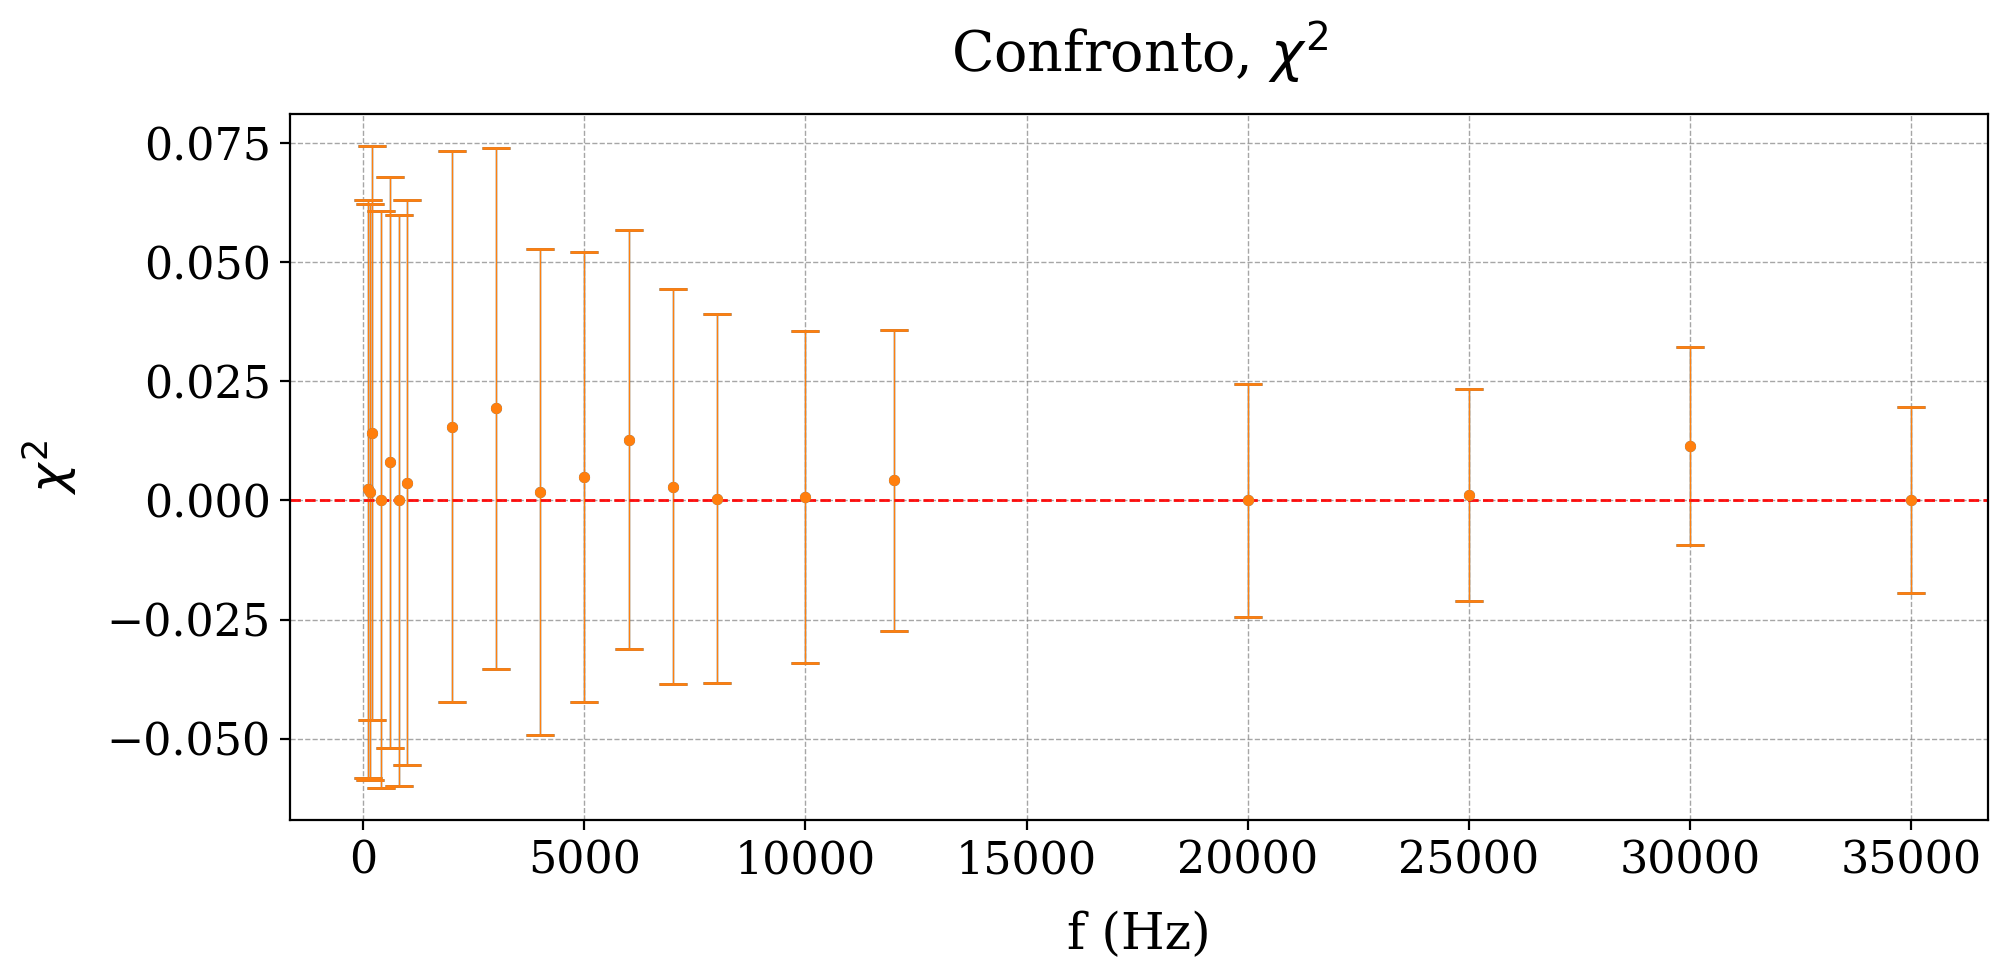

In [102]:
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + r", $\chi^2$",xlabel=xlabel,ylabel=r"$\chi^2$")

for j,key in enumerate(keys):
    xdata, ydata = data[key]
    chi = chi_quadri[key]
    ax.errorbar(chi[0],chi[1],yerr=chi[2],
                **gf.errorbar_params, color=gf.colori[j])
    ax.axhline(0,
            **gf.line_params, color='red')

gf.salva_grafico(fig,cartella + "/" + grafico_output3)